# Exploratory Data Analysis

In [11]:
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

## Data Import

In [12]:
df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train.parquet'))

df.head()

,access_route,state,origin_country,month,year,arrival_count,month_num,date
0,Aérea,Amazonas,África do Sul,Janeiro,1989,9.0,01,1989-01-31
1,Aérea,Amazonas,Angola,Janeiro,1989,0.0,01,1989-01-31
2,Aérea,Amazonas,Nigéria,Janeiro,1989,0.0,01,1989-01-31
3,Aérea,Amazonas,Outros países,Janeiro,1989,0.0,01,1989-01-31
4,Aérea,Amazonas,Costa Rica,Janeiro,1989,6.0,01,1989-01-31


## Feature Analysis

### Access Route

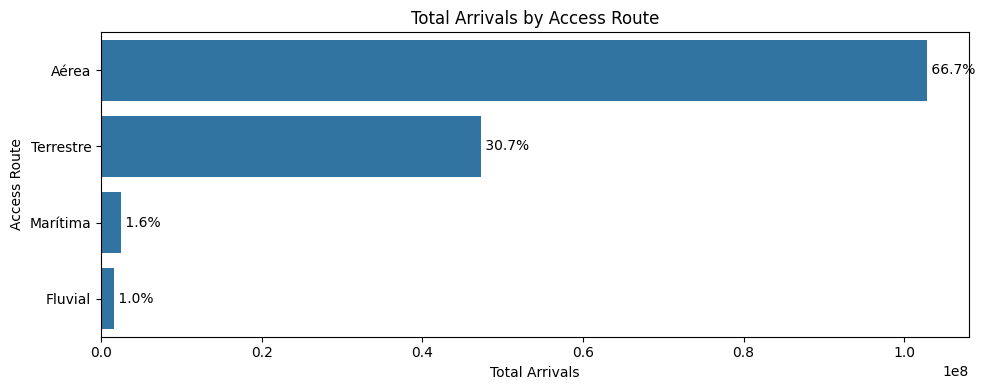

In [13]:
top_access_route = pd.DataFrame(
    df.groupby('access_route')['arrival_count'].sum().nlargest(20)
)
top_access_route['percentage'] = (
    top_access_route['arrival_count'] / top_access_route['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=top_access_route['arrival_count'], y=top_access_route.index)
plt.title('Total Arrivals by Access Route')
plt.xlabel('Total Arrivals')
plt.ylabel('Access Route')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_access_route["arrival_count"], top_access_route["percentage"])
):
    ax.text(count, i, f" {pct:.1f}%", va="center", ha="left")

plt.tight_layout()
